# Visualizations

Now that we have determined our feature importances, we'll explore our data visually.

### Common Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl

In [2]:
# suppress warnings
import warnings

warnings.filterwarnings("ignore")

### Load Data

In [3]:
df = pkl.load(open("../../../data/2021/processed/vbac/cleaned_df.pkl", "rb"))

### Univariate Visualization

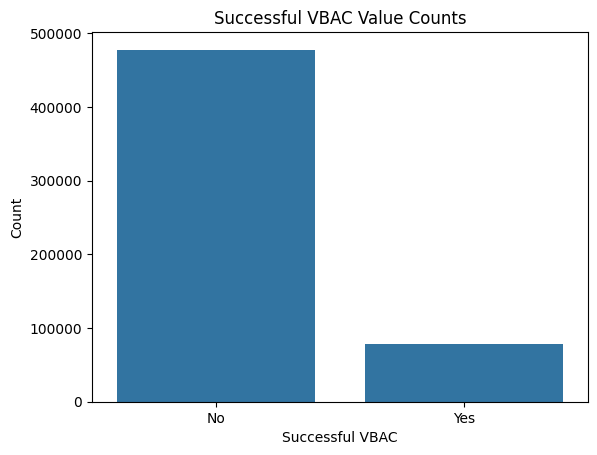

In [20]:
target_value_counts = df["target"].value_counts()

target_bar_ax = sns.barplot(x=target_value_counts.index, y=target_value_counts.values)
target_bar_ax.set_title("Successful VBAC Value Counts")
target_bar_ax.set_xlabel("Successful VBAC")
target_bar_ax.set_ylabel("Count")
target_bar_ax.set_xticklabels(["No", "Yes"])
plt.show()

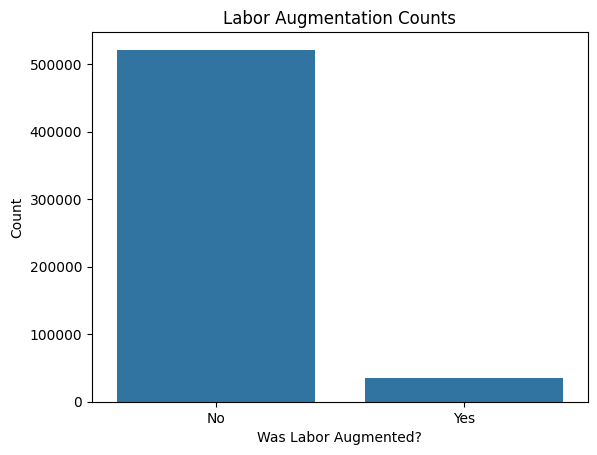

In [4]:
augmentation_of_labor_value_counts = df["augmentation_of_labor"].value_counts()

labor_augmentation_bar_ax = sns.barplot(
    x=augmentation_of_labor_value_counts.index,
    y=augmentation_of_labor_value_counts.values,
)
labor_augmentation_bar_ax.set_title("Labor Augmentation Counts")
labor_augmentation_bar_ax.set_xlabel("Was Labor Augmented?")
labor_augmentation_bar_ax.set_xticklabels(["No", "Yes"])
labor_augmentation_bar_ax.set_ylabel("Count")
plt.show()

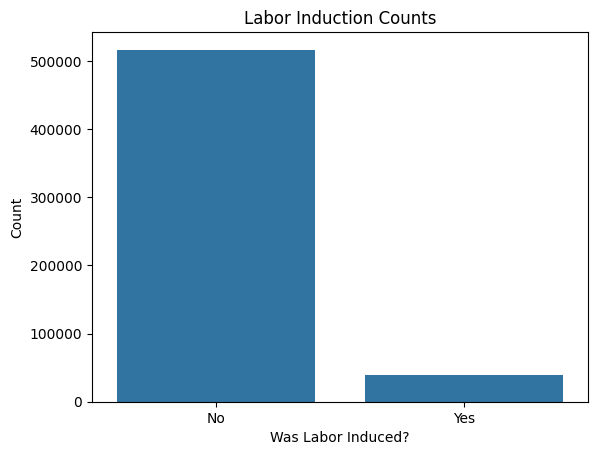

In [5]:
induction_of_labor_value_counts = df["induction_of_labor"].value_counts()

induction_of_labor_bar_ax = sns.barplot(
    x=induction_of_labor_value_counts.index,
    y=induction_of_labor_value_counts.values,
)
induction_of_labor_bar_ax.set_title("Labor Induction Counts")
induction_of_labor_bar_ax.set_xlabel("Was Labor Induced?")
induction_of_labor_bar_ax.set_xticklabels(["No", "Yes"])
induction_of_labor_bar_ax.set_ylabel("Count")
plt.show()

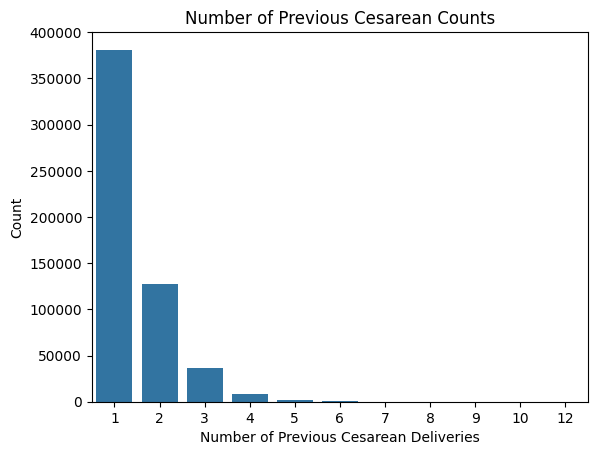

In [6]:
number_of_previous_cesarean_value_counts = df[
    "number_of_previous_cesarean"
].value_counts()

number_of_previous_cesarean_bar_ax = sns.barplot(
    x=number_of_previous_cesarean_value_counts.index,
    y=number_of_previous_cesarean_value_counts.values,
)
number_of_previous_cesarean_bar_ax.set_title("Number of Previous Cesarean Counts")
number_of_previous_cesarean_bar_ax.set_xlabel("Number of Previous Cesarean Deliveries")
number_of_previous_cesarean_bar_ax.set_ylabel("Count")
plt.show()

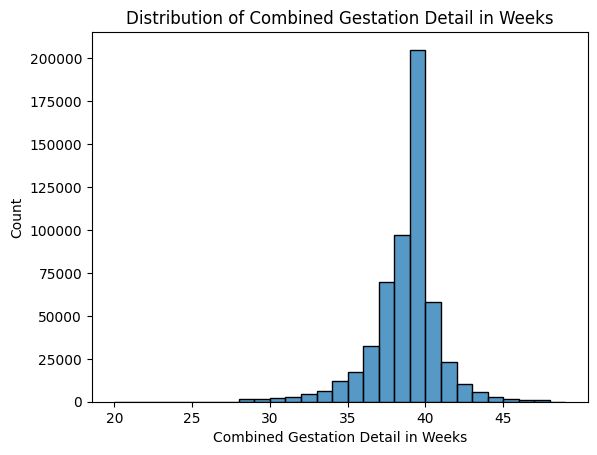

In [7]:
combined_gestation_detail_value_counts = df[
    "combined_gestation_detail_in_weeks"
].value_counts()

combined_gestation_detail_bar_ax = sns.histplot(
    x=combined_gestation_detail_value_counts.index,
    weights=combined_gestation_detail_value_counts.values,
    bins=range(20, 50, 1),
)
combined_gestation_detail_bar_ax.set_title(
    "Distribution of Combined Gestation Detail in Weeks"
)
combined_gestation_detail_bar_ax.set_xlabel("Combined Gestation Detail in Weeks")
combined_gestation_detail_bar_ax.set_xticks(ticks=range(20, 50, 5))
combined_gestation_detail_bar_ax.set_ylabel("Count")
plt.show()

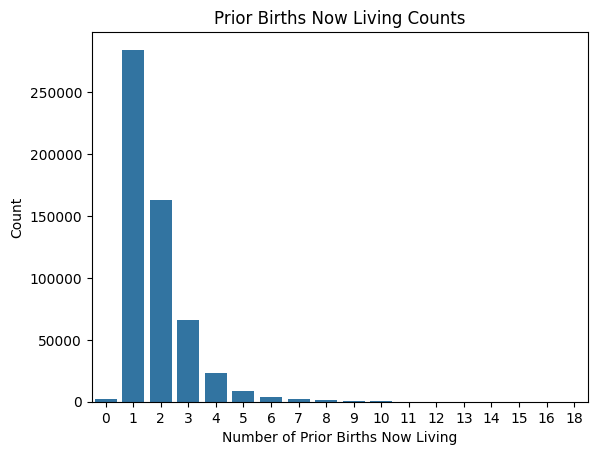

In [8]:
prior_births_now_living_value_counts = df["prior_births_now_living"].value_counts()

prior_births_now_living_bar_ax = sns.barplot(
    x=prior_births_now_living_value_counts.index,
    y=prior_births_now_living_value_counts.values,
)
prior_births_now_living_bar_ax.set_title("Prior Births Now Living Counts")
prior_births_now_living_bar_ax.set_xlabel("Number of Prior Births Now Living")
prior_births_now_living_bar_ax.set_ylabel("Count")
plt.show()

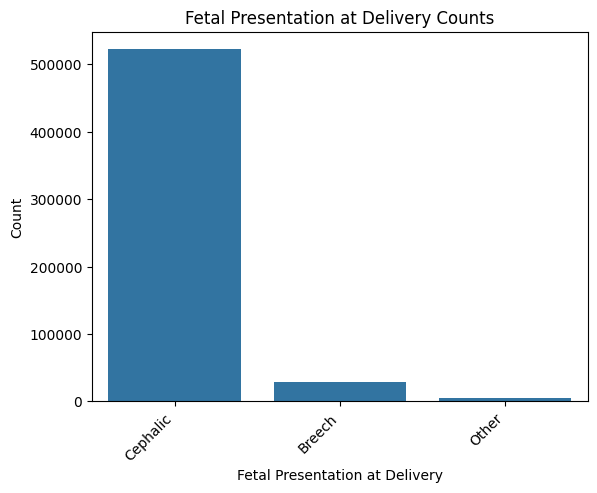

In [9]:
fetal_presentation_at_delivery_value_counts = df[
    "fetal_presentation_at_delivery"
].value_counts()

fetal_presentation_at_delivery_bar_ax = sns.barplot(
    x=fetal_presentation_at_delivery_value_counts.index,
    y=fetal_presentation_at_delivery_value_counts.values,
)
fetal_presentation_at_delivery_bar_ax.set_title("Fetal Presentation at Delivery Counts")
fetal_presentation_at_delivery_bar_ax.set_xlabel("Fetal Presentation at Delivery")
fetal_presentation_at_delivery_bar_ax.set_xticklabels(
    ["Cephalic", "Breech", "Other"],
    rotation=45,
    ha="right",
)
fetal_presentation_at_delivery_bar_ax.set_ylabel("Count")
plt.show()

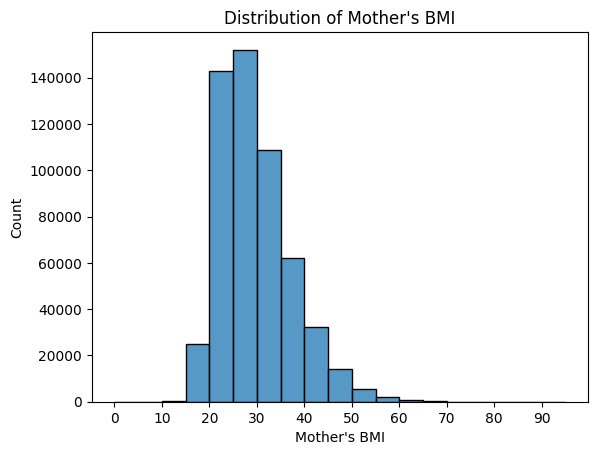

In [10]:
BMI_value_counts = df["BMI"].value_counts()

BMI_bar_ax = sns.histplot(
    x=BMI_value_counts.index, weights=BMI_value_counts.values, bins=range(0, 100, 5)
)
BMI_bar_ax.set_title("Distribution of Mother's BMI")
BMI_bar_ax.set_xlabel("Mother's BMI")
BMI_bar_ax.set_xticks(ticks=range(0, 100, 10))
BMI_bar_ax.set_ylabel("Count")
plt.show()

### Bivariate Visualizations

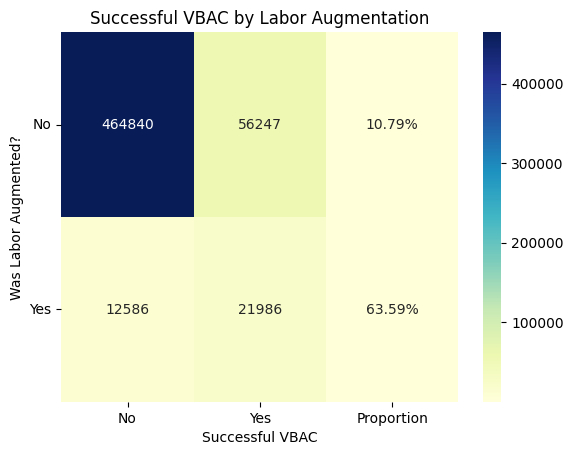

In [11]:
augmentation_of_labor_cross_tab = pd.crosstab(df["augmentation_of_labor"], df["target"])

augmentation_of_labor_cross_tab["proportion"] = (
    augmentation_of_labor_cross_tab[1]
    / (augmentation_of_labor_cross_tab[0] + augmentation_of_labor_cross_tab[1])
    * 100
)

annotation_matrix = augmentation_of_labor_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(
    augmentation_of_labor_cross_tab["proportion"], 2
)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

augmentation_of_labor_cross_tab_ax = sns.heatmap(
    augmentation_of_labor_cross_tab,
    annot=annotation_matrix.values,
    fmt="",
    cmap="YlGnBu",
)
augmentation_of_labor_cross_tab_ax.set_title("Successful VBAC by Labor Augmentation")
augmentation_of_labor_cross_tab_ax.set_xlabel("Successful VBAC")
augmentation_of_labor_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
augmentation_of_labor_cross_tab_ax.set_ylabel("Was Labor Augmented?")
augmentation_of_labor_cross_tab_ax.set_yticklabels(["No", "Yes"], rotation=0)
plt.show()

Labor is not augmented in most cases; however, when it is augmented, it results in significantly more sucessful VBACs.

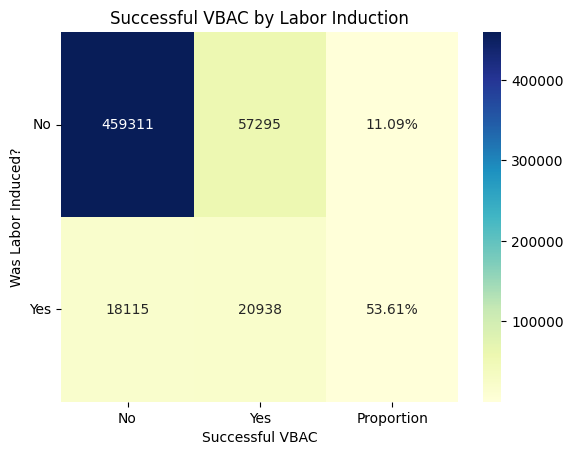

In [12]:
induction_of_labor_cross_tab = pd.crosstab(df["induction_of_labor"], df["target"])

induction_of_labor_cross_tab["proportion"] = (
    induction_of_labor_cross_tab[1]
    / (induction_of_labor_cross_tab[0] + induction_of_labor_cross_tab[1])
    * 100
)

annotation_matrix = induction_of_labor_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(induction_of_labor_cross_tab["proportion"], 2)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

induction_of_labor_cross_tab_ax = sns.heatmap(
    induction_of_labor_cross_tab, annot=annotation_matrix.values, fmt="", cmap="YlGnBu"
)
induction_of_labor_cross_tab_ax.set_title("Successful VBAC by Labor Induction")
induction_of_labor_cross_tab_ax.set_xlabel("Successful VBAC")
induction_of_labor_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
induction_of_labor_cross_tab_ax.set_ylabel("Was Labor Induced?")
induction_of_labor_cross_tab_ax.set_yticklabels(["No", "Yes"], rotation=0)
plt.show()

Labor Induction also results in a significant increase in VBAC success, though not as significant as labor augmentation.

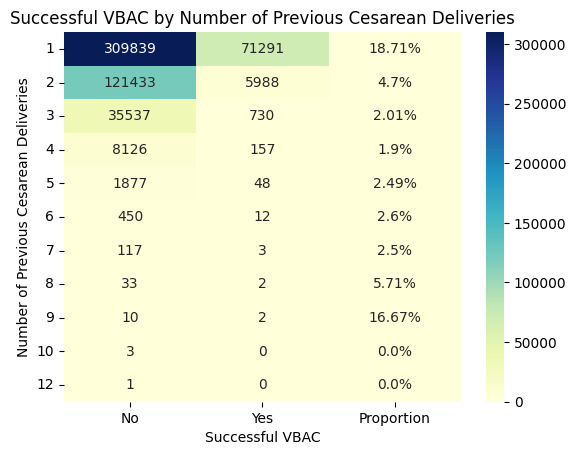

In [13]:
number_of_previous_cesarean_cross_tab = pd.crosstab(
    df["number_of_previous_cesarean"][df["number_of_previous_cesarean"] != 99],
    df["target"],
)
number_of_previous_cesarean_cross_tab["proportion"] = (
    number_of_previous_cesarean_cross_tab[1]
    / (
        number_of_previous_cesarean_cross_tab[0]
        + number_of_previous_cesarean_cross_tab[1]
    )
    * 100
)

annotation_matrix = number_of_previous_cesarean_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(
    number_of_previous_cesarean_cross_tab["proportion"], 2
)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

number_of_previous_cesarean_cross_tab_ax = sns.heatmap(
    number_of_previous_cesarean_cross_tab,
    annot=annotation_matrix.values,
    fmt="",
    cmap="YlGnBu",
)
number_of_previous_cesarean_cross_tab_ax.set_title(
    "Successful VBAC by Number of Previous Cesarean Deliveries"
)
number_of_previous_cesarean_cross_tab_ax.set_xlabel("Successful VBAC")
number_of_previous_cesarean_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
number_of_previous_cesarean_cross_tab_ax.set_ylabel(
    "Number of Previous Cesarean Deliveries"
)
number_of_previous_cesarean_cross_tab_ax.set_yticklabels(
    number_of_previous_cesarean_cross_tab.index, rotation=0
)
plt.show()

The more c-sections a mother has had, the less likely she is to have a successful VBAC.

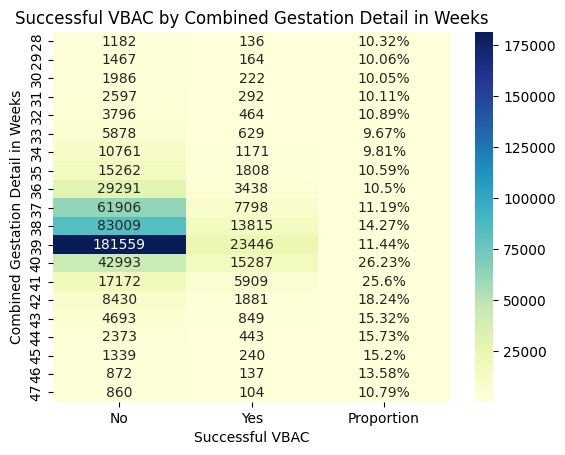

In [14]:
combined_gestation_detail_cross_tab = pd.crosstab(
    df["combined_gestation_detail_in_weeks"],
    df["target"],
)
combined_gestation_detail_cross_tab["proportion"] = (
    combined_gestation_detail_cross_tab[1]
    / (combined_gestation_detail_cross_tab[0] + combined_gestation_detail_cross_tab[1])
) * 100

annotation_matrix = combined_gestation_detail_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(
    combined_gestation_detail_cross_tab["proportion"], 2
)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

combined_gestation_detail_cross_tab_ax = sns.heatmap(
    combined_gestation_detail_cross_tab,
    annot=annotation_matrix.values,
    fmt="",
    cmap="YlGnBu",
)
combined_gestation_detail_cross_tab_ax.set_title(
    "Successful VBAC by Combined Gestation Detail in Weeks"
)
combined_gestation_detail_cross_tab_ax.set_xlabel("Successful VBAC")
combined_gestation_detail_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
combined_gestation_detail_cross_tab_ax.set_ylabel("Combined Gestation Detail in Weeks")
plt.show()

Of term or near-term deliveries, those at 40-41 weeks are most likely to have successful VBACs.

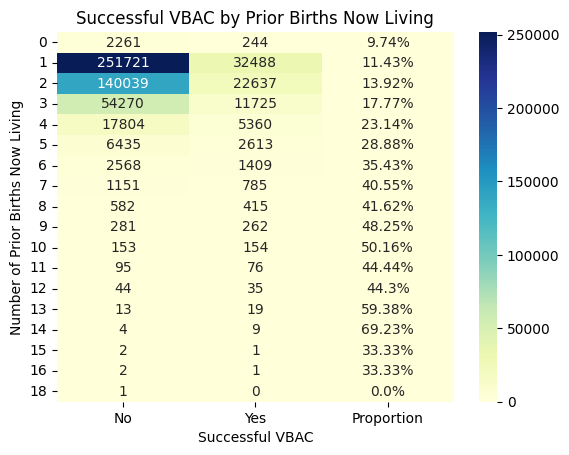

In [15]:
prior_births_now_living_cross_tab = pd.crosstab(
    df["prior_births_now_living"], df["target"]
)

prior_births_now_living_cross_tab["proportion"] = (
    prior_births_now_living_cross_tab[1]
    / (prior_births_now_living_cross_tab[0] + prior_births_now_living_cross_tab[1])
) * 100

annotation_matrix = prior_births_now_living_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(
    prior_births_now_living_cross_tab["proportion"], 2
)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

prior_births_now_living_cross_tab_ax = sns.heatmap(
    prior_births_now_living_cross_tab,
    annot=annotation_matrix.values,
    fmt="",
    cmap="YlGnBu",
)
prior_births_now_living_cross_tab_ax.set_title(
    "Successful VBAC by Prior Births Now Living"
)
prior_births_now_living_cross_tab_ax.set_xlabel("Successful VBAC")
prior_births_now_living_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
prior_births_now_living_cross_tab_ax.set_ylabel("Number of Prior Births Now Living")
prior_births_now_living_cross_tab_ax.set_yticklabels(
    prior_births_now_living_cross_tab.index, rotation=0
)
plt.show()

The more children a mother has borne, the more likely she is to have a successful VBAC. This is counterintuitive, but our suspicion is that this may be better explored in the multivariate visualizations in conjunction with number of previous c-sections.

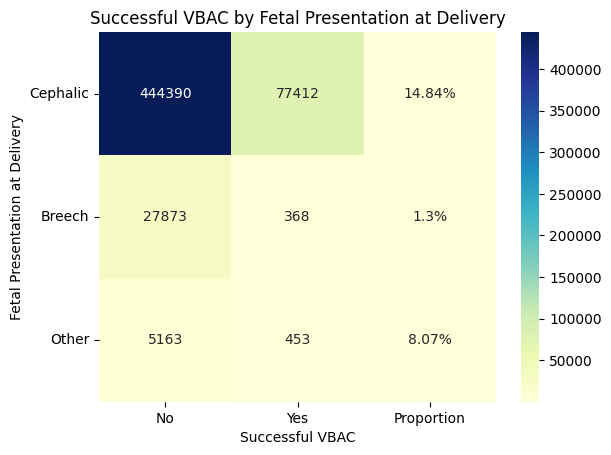

In [16]:
fetal_presentation_at_delivery_cross_tab = pd.crosstab(
    df["fetal_presentation_at_delivery"], df["target"]
)

fetal_presentation_at_delivery_cross_tab["proportion"] = (
    fetal_presentation_at_delivery_cross_tab[1]
    / (
        fetal_presentation_at_delivery_cross_tab[0]
        + fetal_presentation_at_delivery_cross_tab[1]
    )
    * 100
)

annotation_matrix = fetal_presentation_at_delivery_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(
    fetal_presentation_at_delivery_cross_tab["proportion"], 2
)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

fetal_presentation_at_delivery_cross_tab_ax = sns.heatmap(
    fetal_presentation_at_delivery_cross_tab,
    annot=annotation_matrix.values,
    fmt="",
    cmap="YlGnBu",
)
fetal_presentation_at_delivery_cross_tab_ax.set_title(
    "Successful VBAC by Fetal Presentation at Delivery"
)
fetal_presentation_at_delivery_cross_tab_ax.set_xlabel("Successful VBAC")
fetal_presentation_at_delivery_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
fetal_presentation_at_delivery_cross_tab_ax.set_ylabel("Fetal Presentation at Delivery")
fetal_presentation_at_delivery_cross_tab_ax.set_yticklabels(
    ["Cephalic", "Breech", "Other"], rotation=0
)
plt.show()

Cephalic presentation has the highest VBAC success rate, which is expected.

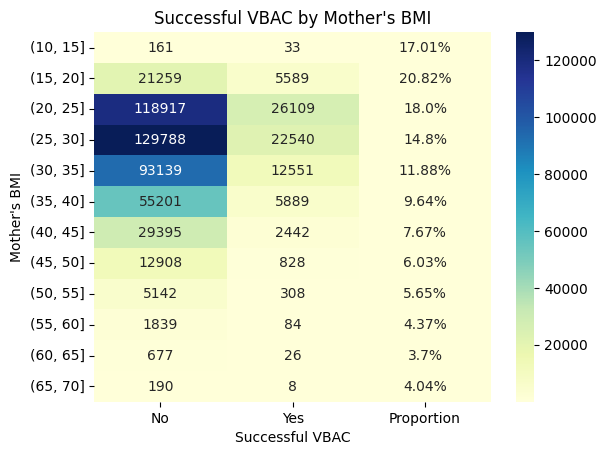

In [17]:
BMI_cross_tab = pd.crosstab(pd.cut(df["BMI"], bins=range(0, 100, 5)), df["target"])
BMI_cross_tab["proportion"] = (
    BMI_cross_tab[1] / (BMI_cross_tab[0] + BMI_cross_tab[1])
) * 100

annotation_matrix = BMI_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(BMI_cross_tab["proportion"], 2)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

BMI_cross_tab_ax = sns.heatmap(
    BMI_cross_tab, annot=annotation_matrix.values, fmt="", cmap="YlGnBu"
)
BMI_cross_tab_ax.set_title("Successful VBAC by Mother's BMI")
BMI_cross_tab_ax.set_xlabel("Successful VBAC")
BMI_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
BMI_cross_tab_ax.set_ylabel("Mother's BMI")
BMI_cross_tab_ax.set_yticklabels(BMI_cross_tab.index.astype(str), rotation=0)
plt.show()

The higher a mother's BMI, the less likely she is to have a successful VBAC.

### 4. Multivariate Visualizations

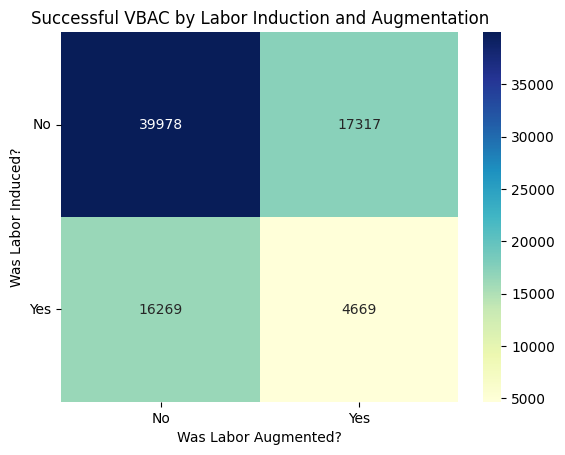

In [18]:
induction_augmentation_cross_tab = pd.crosstab(
    df["induction_of_labor"],
    df["augmentation_of_labor"],
    values=df["target"],
    aggfunc="sum",
)

induction_augmentation_cross_tab_ax = sns.heatmap(
    induction_augmentation_cross_tab, annot=True, fmt="d", cmap="YlGnBu"
)
induction_augmentation_cross_tab_ax.set_title(
    "Successful VBAC by Labor Induction and Augmentation"
)
induction_augmentation_cross_tab_ax.set_xlabel("Was Labor Augmented?")
induction_augmentation_cross_tab_ax.set_xticklabels(["No", "Yes"])
induction_augmentation_cross_tab_ax.set_ylabel("Was Labor Induced?")
induction_augmentation_cross_tab_ax.set_yticklabels(["No", "Yes"], rotation=0)
plt.show()

Of our successful VBACs, the majority occurred naturally (as in, without induction or augmentation). We can conclude that both inducing and augmenting labor does not necessarily produce better results. This likely is because a birth attendant is unlikely to augment labor in a mother who has had a previous c-section, and instead opts for a repeat c-section.

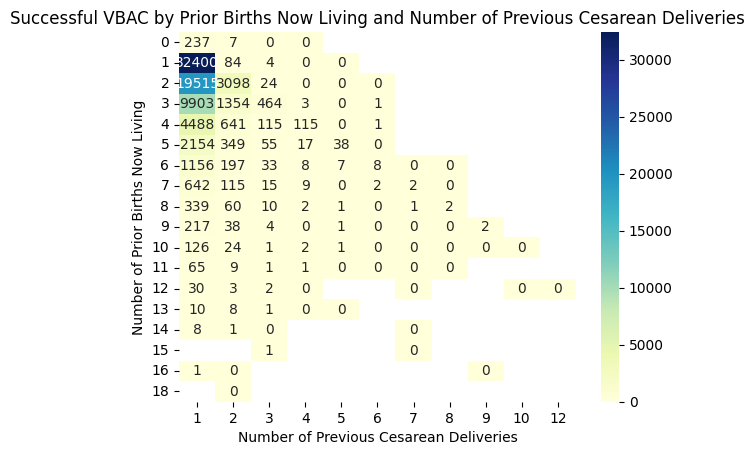

In [19]:
prior_births_previous_cesarean_cross_tab = pd.crosstab(
    df["prior_births_now_living"],
    df["number_of_previous_cesarean"],
    values=df["target"],
    aggfunc="sum",
)

prior_births_previous_cesarean_cross_tab_ax = sns.heatmap(
    prior_births_previous_cesarean_cross_tab, annot=True, fmt=".0f", cmap="YlGnBu"
)
prior_births_previous_cesarean_cross_tab_ax.set_title(
    "Successful VBAC by Prior Births Now Living and Number of Previous Cesarean Deliveries"
)
prior_births_previous_cesarean_cross_tab_ax.set_xlabel(
    "Number of Previous Cesarean Deliveries"
)
prior_births_previous_cesarean_cross_tab_ax.set_xticklabels(
    prior_births_previous_cesarean_cross_tab.columns, rotation=0
)
prior_births_previous_cesarean_cross_tab_ax.set_ylabel(
    "Number of Prior Births Now Living"
)
prior_births_previous_cesarean_cross_tab_ax.set_yticklabels(
    prior_births_previous_cesarean_cross_tab.index, rotation=0
)
plt.show()

A successful VBAC is most likely to occur after 1 previous c-section. The more prior births and c-sections that have occurred, the less likely a successful VBAC becomes.

### Conclusion

Our cleaned data reflects the same trends as our raw data. We can now move on to training our models.